# Проект 18 спринта: выявление рисков в доставке логистической компании CargaPronto

Выполнил: Артем Буров (DS12)  
Дата: 20/09/2026  
GitHub: https://github.com/TemaQDX/sprint_18_project_carga_pronto

## Описание проекта

Компания CargaPronto — крупнейший логистический оператор, связывающий производственные хабы Пуэрто-Рико с потребителями в США. В последнее время бизнес столкнулся с острым кризисом: 55 % заказов доставляются с задержкой, а объём штрафов за нарушение SLA за прошлый квартал превысил бюджет на развитие IT‑инфраструктуры. Крупнейшие ритейлеры США поставили ультиматум о необходимости стабилизации сроков доставки, иначе контракты будут расторгнуты.

Внутри компании нет единого понимания причин задержек: департамент транспорта связывает проблему с внешними факторами и неоднородностью клиентской базы — в частности, со сложными локациями и особенностями поведения отдельных потребителей. Представители отдела считают, что невозможно обеспечить одинаковые сроки доставки для всех клиентов из‑за существенных различий в их профилях.

Цель текущего проекта как независимого консультанта — проверить гипотезу о том, что задержки обусловлены не сбоями в логистике, а спецификой самих клиентов. Необходимо сегментировать клиентскую базу, выделить проблемные группы и доказать, что тип потребителя можно использовать для прогнозирования риска задержки ещё на этапе оформления заказа. Это позволит компании точечно корректировать приоритеты доставки и сократить объём штрафных выплат.

## Цель и задача проекта

**Цель проекта** — создать систему поддержки принятия решений для логистов CargaPronto, которая в момент оформления заказа в реальном времени оценивает риск задержки и выдаёт предупреждение, если вероятность опоздания превышает 70%. Получив такой сигнал, диспетчер или автоматизированная система управления складом может принять одно из нескольких корректирующих действий: повысить приоритет сборки заказа, за счёт компании перевести доставку в более быстрый режим (например, с Standard Class до First Class или Second Day), назначить на сложный маршрут более опытного курьера или дополнительный транспорт, заранее уведомить клиента о возможной задержке — что в логистике часто не считается нарушением лояльности, — либо перепроверить актуальность заказа с клиентом, склонным к возвратам. Такой подход позволяет не просто констатировать факт опоздания постфактум, а активно управлять ситуацией ещё до отгрузки, снижая объёмы штрафных выплат и удерживая лояльность клиентов.

**Задача проекта** — построить модель бинарной классификации, которая на основе входных данных о заказе и профиле клиента предсказывает вероятность задержки доставки. Положительный класс — заказ с задержкой, отрицательный — заказ, доставленный вовремя. Модель должна работать достаточно быстро, чтобы интеграция в процесс оформления заказа происходила в реальном времени.

В качестве инструментов предусмотрены два алгоритма. Логистическая регрессия выбрана как базовая модель: она ценится в бизнесе за высокую скорость и прозрачность, позволяет оценить «нижнюю планку» качества до применения более сложных методов. В качестве основной модели используется градиентный бустинг CatBoost — он способен находить сложные нелинейные закономерности в данных и эффективно работать с категориальными признаками, что особенно важно при сегментировании клиентской базы.

Основная метрика качества — ROC-AUC. Выбор обусловлен тем, что метрика оценивает способность модели ранжировать заказы по степени риска, а не просто порогово классифицировать их. Это позволяет диспетчерам CargaPronto точечно выделять те доставки, которым действительно нужно больше внимания, и гибко управлять порогом срабатывания предупреждений. Удовлетворительным результатом для проекта считается значение ROC-AUC выше 0,75.

Внедрение такой системы переводит CargaPronto от реактивной модели работы — выплаты штрафов по факту опоздания — к проактивной: компания получает возможность предотвращать задержки до того, как заказ покинет склад, и управлять ресурсами исходя из прогнозируемого риска, а не ограничиваться разбором причин уже случившихся срывов.


## Описание данных

### Датасет профилей клиентов (`ds_s18_customers.csv`)

Агрегированная информация о каждом уникальном клиенте из ERP-системы. Признаки характеризуют пользователей с географической и поведенческой сторон. Поведенческие признаки собраны по методологии RFM — стандарту сегментации в ритейле и логистике, позволяющему отделить лояльных клиентов от случайных покупателей. Помимо базовых RFM-показателей, датасет содержит данные о средней скидке и доле возвратов. На основе географических координат и поведенческих метрик планируется создание новых признаков с помощью обучения без учителя: геокластеров (группировка клиентов по реальным логистическим зонам) и поведенческих сегментов (выделение групп на основе RFM, скидки и возвратов).

| Признак | Описание |
|---|---|
| `customer_id` | Уникальный номер клиента в ERP. Ключ для связи с таблицей заказов. |
| `customer_lat` | Широта местонахождения клиента. |
| `customer_lon` | Долгота местонахождения клиента. |
| `recency` | Количество дней с момента последнего заказа до точки отсчёта (Recency). |
| `total_orders` | Общее количество заказов клиента (Frequency). |
| `total_sales` | Суммарная выручка от клиента за всё время (Monetary). |
| `avg_discount` | Средний размер скидки, получаемой клиентом. Маркер чувствительности к акциям. |
| `return_rate` | Доля проблемных заказов (возвраты и отмены). Ключевой показатель добросовестности клиента. |

### Датасет заказов (`ds_s18_orders.csv`)

Таблица событий, где зафиксирован каждый факт продажи и итог доставки. Именно здесь находится целевая переменная проекта — `late_delivery_risk`. Каждая строка описывает отдельный заказ: дату совершения, категорию товара, стоимость и выбранный режим доставки. Заказы связаны с профилями клиентов через `customer_id`, что позволяет объединять поведенческие и географические характеристики клиента с параметрами конкретного заказа для предсказания риска задержки.

| Признак | Описание |
|---|---|
| `order_id` | Уникальный номер заказа. |
| `customer_id` | Идентификатор клиента. Ключ для связи с профилем из таблицы клиентов. |
| `order_date` | Дата и время совершения покупки. |
| `category_name` | Категория заказанного товара. |
| `item_price` | Стоимость товара в заказе. |
| `shipping_mode` | Выбранный режим доставки: Standard Class, First Class, Second Class, Same Day. |
| `late_delivery_risk` | Целевая переменная: 1 — заказ доставлен с задержкой, 0 — доставлен вовремя. |


##  Импорт библиотек, выполнение базовых настроек

Загрузите все необходимые для выполнения проекта библиотеки и другие компоненты.



In [1]:
# Загружаем базовые библиотеки
import numpy as np
import pandas as pd

# Загружаем библиотеку для расчёта коэффициента корреляции Phik
from phik import phik_matrix

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Географическая визуализация
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Загрузка модулей sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, recall_score, precision_score, roc_auc_score, confusion_matrix, brier_score_loss, roc_curve, auc
from sklearn.linear_model import LogisticRegression

# Импортируем CatBoost для задачи регрессии
from catboost import CatBoostRegressor

# Импорт Optuna
import optuna

# Импорт shap
import shap

# Системные библиотеки, настройки отображения датафреймов и предупредительных сообщений
import re
import cyrtranslit

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

RANDOM_SEED = 57
hlink = 'https://code.s3.yandex.net/datasets/'

## Подготовка классов и функций

In [2]:
# =========================
# Функция оптимизации датафрейма

def optimize_dataframe(df: pd.DataFrame, col_translation: dict | None = None) -> pd.DataFrame:
    """
    Оптимизирует имена колонок и типы данных в DataFrame.
    
    Параметры:
        df: входной DataFrame.
        col_translation: словарь {русское_имя: английское_имя}. Если None или ключ отсутствует,
                          применяется транслитерация. Для уже английских имён — только snake_case.
    
    Возвращает:
        Оптимизированный DataFrame.
    """

    # 0. Функция формирования уникальных имён (на случай дублей после транслитерации)
    def make_unique_columns(cols):
        seen = {}
        new_cols = []
        for c in cols:
            if c not in seen:
                seen[c] = 1
                new_cols.append(c)
            else:
                seen[c] += 1
                new_cols.append(f"{c}_{seen[c]}")
        return new_cols

    # 1. Замена по словарю ИЛИ транслитерация
    def normalize_col_name(col: str) -> str:
        col = str(col).strip()

        # Если имя уже английское (нет кириллицы) — сразу к snake_case
        if not any('а' <= ch <= 'я' or 'А' <= ch <= 'Я' for ch in col):
            return col

        # Если есть перевод в словаре — используем его
        if col_translation and col in col_translation:
            return col_translation[col]

        # Иначе — транслитерация
        return cyrtranslit.to_latin(col, 'ru')

    df.columns = df.columns.map(normalize_col_name)

    # 2. Приводим к нижнему регистру
    df.columns = df.columns.astype(str).str.lower()

    # 3. Убираем апострофы и кавычки отдельно (это частая проблема cyrtranslit)
    df.columns = df.columns.str.replace(r"['\"‘’`]", "", regex=True)

    # 4. Заменяем любые не-буквенно-цифровые символы (кроме подчёркивания) на _
    df.columns = df.columns.str.replace(r'[^a-z0-9_]', '_', regex=True)

    # 5. Схлопываем множественные подчёркивания и убираем их по краям
    df.columns = df.columns.str.replace(r'_+', '_', regex=True).str.strip('_')

    # 6. Защита от пустых имён колонок
    empty_cols = df.columns == ''
    if empty_cols.any():
        for i, col in enumerate(df.columns):
            if col == '':
                df.columns.values[i] = f'col_{i}'

    # 7. Делаем имена уникальными (на случай дублей после транслитерации)
    df.columns = make_unique_columns(df.columns)

    # 8. Оптимизация типов float
    float_cols = df.select_dtypes(include=['float64', 'float32']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # 9. Оптимизация типов int
    int_cols = df.select_dtypes(include=['int64', 'int32']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    return df

# =========================
# Анализ пропущенных значений

def show_missing_stats(df):
    """
    Функция для отображения статистики пропущенных значений в DataFrame.
    """
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isnull().sum(),
        'Доля пропусков': df.isnull().mean()
    }).sort_values(by='Кол-во пропусков', ascending=False)
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        print("Пропусков в данных нет")
        return
    
    # Форматируем при выводе через Styler
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))

# ========================
# histogram
def histogram_chart(df, attr='Признак', bins=10, kde=True, figsize=(10,6), title_text='Распределение признака', ylabel='Число наблюдений', xlabel='Признак'):
    _, ax = plt.subplots(figsize=figsize)
    sns.histplot(data=df, x=attr, bins=bins, ax=ax, kde=kde)
    plt.title(title_text)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    median_val = df[attr].median()
    mean_val = df[attr].mean()
    plt.axvline(median_val, color='red', linestyle='--', label=f'Медиана: {median_val:.1f}')
    plt.axvline(mean_val, color='purple', linestyle='-.', label=f'Средняя: {mean_val:.1f}')
    plt.legend()
    plt.show()

# =========================
# boxplot
def boxplot_chart(df, feature_list, diagram_name='Диаграммы размаха значений количественных признаков'):
    n_plots = len(feature_list)
    _, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(12, 2 * n_plots), squeeze=False)
    
    for i, feature in enumerate(feature_list):
        df[feature].plot.box(ax=axes[i, 0], vert=False)
        axes[i, 0].set_title(f'Boxplot: {feature}')
        axes[i, 0].tick_params(axis='x', labelrotation=0)
        axes[i, 0].grid(axis='x', alpha=0.5)

    plt.suptitle(diagram_name, fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


# =========================
# bar chart
def plot_bar_chart(
    data,
    figsize=(12, 6),
    xlabel='Категория',
    ylabel='Количество наблюдений',
    title='Столбчатая диаграмма',
    top_n=5,
    x_tick_rotation=0
):
    if not isinstance(data, pd.Series):
        data = pd.Series(data)

    value_counts = data.value_counts().head(top_n)
    value_counts_normalized = data.value_counts(normalize=True).head(top_n)
    total = value_counts.sum()

    plt.figure(figsize=figsize)

    ax = value_counts.plot(
        kind='bar',
        xlabel=xlabel,
        ylabel=ylabel,
        rot=x_tick_rotation,
        legend=False,
        title=title
    )

    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, v in enumerate(value_counts):
        y_offset = 0.001 * total
        ax.text(i, v + y_offset, str(v), ha='center', va='bottom', fontsize=10)

    for i, v in enumerate(value_counts_normalized):
        y_pos = (v * total) / 2
        ax.text(
            i, y_pos, f'{v * 100:.1f}%',
            ha='center', va='center', fontsize=10, color='white', fontweight='bold'
        )

    plt.tight_layout()
    plt.show()

# =========================
# phik heatmap
def phik_coolwarm_matrix(df, target_var, interval_cols, matrix_view=True, figsize=(12, 12)):
    
    plt.figure(figsize=figsize)
    correlation_matrix = df.phik_matrix(interval_cols=interval_cols)
    if matrix_view:
        data_heatmap = correlation_matrix
    else:
        data_heatmap = correlation_matrix.loc[correlation_matrix.index != target_var][[target_var]].sort_values(by=target_var, ascending=False)
    sns.heatmap(data_heatmap,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                linewidths=0.5,
                cbar=False
            )
    plt.yticks(rotation=0)
    plt.title('Тепловая карта коэффициента Phik \n')
    plt.show()

# =========================
# Для log и sqrt преобразования признаков в пайплайне препроцессора данных создаем собственный class
# =========================

# Класс преобразования числовых признаков log и sqrt
class LogSqrtTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, log_cols=None, sqrt_cols=None):
        self.log_cols = log_cols if log_cols is not None else []
        self.sqrt_cols = sqrt_cols if sqrt_cols is not None else []

    def fit(self, X, y=None):
        # Сохраняем имена признаков на входе
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = list(X.columns)
        else:
            # X.shape — это кортеж (n_rows, n_cols), нам нужно количество признаков (столбцов)
            n_features = X.shape[1]
            self.feature_names_in_ = [f"x{i}" for i in range(n_features)]
        return self

    def transform(self, X):
        # Если на вход пришёл numpy array — оборачиваем в DataFrame с правильными именами
        if isinstance(X, np.ndarray):
            # Используем X.shape[1], чтобы получить число столбцов, а не весь кортеж
            n_features = X.shape[1]
            columns = getattr(self, 'feature_names_in_', [f"x{i}" for i in range(n_features)])
            # Для numpy-массива нет index, поэтому передаём None
            X = pd.DataFrame(X, columns=columns)
        else:
            X = X.copy()

        # Фильтруем колонки, которые реально есть в данных
        existing_log_cols = [c for c in self.log_cols if c in X.columns]
        existing_sqrt_cols = [c for c in self.sqrt_cols if c in X.columns]

        # Применяем трансформации и создаём новые колонки
        for col in existing_log_cols:
            new_col = f"{col}_log"
            # Перезаписываем, если колонка уже есть (на случай повторного вызова)
            X[new_col] = np.log1p(X[col])

        for col in existing_sqrt_cols:
            new_col = f"{col}_sqrt"
            X[new_col] = np.sqrt(np.maximum(X[col], 0))

        # Удаляем старые колонки
        cols_to_drop = list(set(existing_log_cols + existing_sqrt_cols))
        X = X.drop(columns=cols_to_drop, errors='ignore')

        # ВАЖНО: всегда возвращаем DataFrame, никаких .values
        return X

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_

        # Логика должна соответствовать тому, что реально делает transform:
        # 1. Старые колонки из log_cols/sqrt_cols удаляются.
        # 2. Добавляются новые колонки с суффиксами _log и _sqrt.
        # 3. Остальные колонки остаются без изменений.

        output_features = []
        log_set = set(self.log_cols)
        sqrt_set = set(self.sqrt_cols)

        for col in input_features:
            if col in log_set:
                output_features.append(f"{col}_log")
            elif col in sqrt_set:
                output_features.append(f"{col}_sqrt")
            else:
                output_features.append(col)

        return np.array(output_features, dtype=object)

## 1. Загрузка данных, первичное знакомство

* Загрузите датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv`.
  * Путь к первому файлу — `'/datasets/ds_s18_customers.csv'`.
  * Путь ко второму файлу — `'/datasets/ds_s18_orders.csv'`.
* Проведите технический аудит данных.
* Выявите и устраните полные дубликаты строк.
* Выполните проверку целостности данных (ID-Check).
* Подготовьте признаки, связанные с датой и временем.
* Создайте дополнительные колонки `order_month`, `order_weekday`, `order_hour`.




In [3]:
hlink = 'https://code.s3.yandex.net/datasets/'

# Загрузка и оптимизация каждого датафрейма отдельно
df_customers = optimize_dataframe(pd.read_csv(hlink + 'ds_s18_customers.csv'))
df_orders = optimize_dataframe(pd.read_csv(hlink + 'ds_s18_orders.csv'))


print("Все датафреймы загружены и оптимизированы")

Все датафреймы загружены и оптимизированы


In [4]:
# Выведем первые строки df_customers
df_customers.head()

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660034,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.199951,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709961,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.920044,3,0.140,0.0,458


In [5]:
# Проверим структуру и типы данных датафрейма df_customers
df_customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 20652 entries, 0 to 20651
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   20652 non-null  int16  
 1   customer_lat  20652 non-null  float32
 2   customer_lon  20652 non-null  float32
 3   total_sales   20652 non-null  float32
 4   total_orders  20652 non-null  int8   
 5   avg_discount  20652 non-null  float32
 6   return_rate   20652 non-null  float32
 7   recency       20652 non-null  int16  
dtypes: float32(5), int16(2), int8(1)
memory usage: 504.3 KB


In [6]:
# Проверка пропусков
show_missing_stats(df_customers)

Пропусков в данных нет


In [7]:
# Проверка уникальности id и состава других атрибутов
# customer_id содержит уникальные значения
df_customers.astype(str).describe()

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
count,20652,20652,20652,20652,20652,20652,20652,20652
unique,20652,11250,4487,12472,15,2266,166,1012
top,1,18.227573,-66.037056,39.35,1,0.1,0.0,120
freq,1,30,1634,47,8884,677,18019,69


In [8]:
# Проверка полный явных дубликатов
# Дубликатов нет
df_customers.duplicated().sum()

np.int64(0)

In [9]:
# Выведем первые строки df_orders
df_orders.head()

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


In [10]:
# Проверим структуру и типы данных датафрейма df_orders
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   order_id            180519 non-null  int32  
 1   customer_id         180519 non-null  int16  
 2   late_delivery_risk  180519 non-null  int8   
 3   shipping_mode       180519 non-null  str    
 4   category_name       180519 non-null  str    
 5   order_date          180519 non-null  str    
 6   item_price          180519 non-null  float32
dtypes: float32(1), int16(1), int32(1), int8(1), str(3)
memory usage: 6.0 MB


In [11]:
# Проверка пропусков
show_missing_stats(df_orders)

Пропусков в данных нет


In [12]:
# Проверка уникальности id и состава других атрибутов
# order_id содержит уникальные значения
df_orders.astype(str).describe()

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
count,180519,180519,180519,180519,180519,180519,180519
unique,180519,20652,2,4,50,65752,75
top,180517,5654,1,Standard Class,Cleats,2016-10-25 14:39:00,59.99
freq,1,47,98977,107752,24551,5,24820


In [13]:
# Проверка полный явных дубликатов
# Дубликатов нет
df_orders.duplicated().sum()

np.int64(0)

In [14]:
# Приведение order_date к типу datetime
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'], errors='coerce')

# Добавление новых атрибутов order_month, order_weekday, order_hour
df_orders['order_month'] = df_orders['order_date'].dt.month
df_orders['order_weekday'] = df_orders['order_date'].dt.dayofweek
df_orders['order_hour'] = df_orders['order_date'].dt.hour

df_orders = optimize_dataframe(df_orders)
df_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   order_id            180519 non-null  int32         
 1   customer_id         180519 non-null  int16         
 2   late_delivery_risk  180519 non-null  int8          
 3   shipping_mode       180519 non-null  str           
 4   category_name       180519 non-null  str           
 5   order_date          180519 non-null  datetime64[us]
 6   item_price          180519 non-null  float32       
 7   order_month         180519 non-null  int8          
 8   order_weekday       180519 non-null  int8          
 9   order_hour          180519 non-null  int8          
dtypes: datetime64[us](1), float32(1), int16(1), int32(1), int8(4), str(2)
memory usage: 6.5 MB


In [15]:
# Проверка целостности данных (ID-Check)
# Заказов-сирок не обнаружено 
orphan_orders = df_orders[~df_orders['customer_id'].isin(df_customers['customer_id'])]
print(f"Количество заказов без клиента: {df_orders[~df_orders['customer_id'].isin(df_customers['customer_id'])].shape[0]}")


Количество заказов без клиента: 0


## Технический аудит данных проекта CargaPronto: итоги загрузки и первичной предобработки

**Загрузка и оптимизация датасетов**

Датасеты `ds_s18_customers.csv` и `ds_s18_orders.csv` успешно загружены в объекты `df_customers` и `df_orders`. Для унификации и снижения потребления памяти применена функция `optimize_dataframe`:
- имена колонок приведены к формату `snake_case`, очищены от спецсимволов и сделаны уникальными;
- типы данных оптимизированы: числовые колонки переведены в минимальные подходящие типы (`int8`, `int16`, `float32`), что существенно сократило потребление памяти.

**Проверка на дубликаты и пропуски**

**df_customers (20 652 строки):**
- пропусков в данных не обнаружено;
- полных дубликатов строк нет;
- `customer_id` — уникальный идентификатор (все 20 652 значения различны).

**df_orders (180 519 строк):**
- пропусков в данных нет;
- полных дубликатов строк не выявлено;
- `order_id` — уникальный ключ (все значения уникальны).

**Целостность данных (ID-Check)**

Выполнена проверка соответствия `customer_id` в таблице заказов справочнику клиентов:

**Результат:** количество «заказов-сирот» равно 0.
Это гарантирует, что каждый заказ можно корректно связать с профилем клиента и применять признаки из `df_customers` без потери строк.

**Подготовка временных признаков**

Колонка `order_date` преобразована к типу `datetime64[us]`. На её основе созданы дополнительные признаки для анализа временных паттернов:
- `order_month` — месяц заказа (значения 1–12);
- `order_weekday` — день недели (0–6, где 0 — понедельник);
- `order_hour` — час суток (0–23).

Эти признаки позволят исследовать влияние сезонности, дня недели и времени суток на риск задержки доставки (`late_delivery_risk`).

**Сводные характеристики датасетов**

| Датасет | Строк | Колонки | Пропуски | Дубликаты | Уникальные `customer_id` | Статус ID-Check |
|---|---|---|---|---|---|---|
| `df_customers` | 20 652 | 8 | 0 | 0 | 20 652 | OK (нет сирот) |
| `df_orders` | 180 519 | 10 (с новыми признаками) | 0 | 0 | — | OK (все ID валидны) |

**Дальнейшие шаги**

1. **Данные готовы к объединению.** Отсутствие «заказов-сирот» позволяет безопасно выполнять JOIN по `customer_id` для формирования единого датасета с клиентскими и заказными признаками.
2. **Оптимизация типов успешна.** Снижение разрядности числовых колонок уменьшает потребление памяти и ускоряет вычисления на последующих этапах ML-пайплайна.
3. **Временные признаки добавлены.** Новые колонки (`order_month`, `order_weekday`, `order_hour`) открывают возможности для анализа временных зависимостей риска задержки.
4. **Качество данных высокое.** Нет пропусков и полных дубликатов, ключи уникальны — это снижает риски утечек и искажений при построении признаков и кросс-валидации.

---


## 2. Исследовательский анализ данныз (EDA)

На этом этапе ваша цель — исследовать структуру данных и подтвердить гипотезы транспортного департамента о «неоднородности» базы. Кроме того, вам предстоит изучить и удалить географические аномалии.

1. Проверьте баланс классов.
2. Выполните географический аудит.
3. Удалите аномалии.
4. Проанализируйте зависимости между признаками.



### 2.1 Проверка балансов классов целевой переменной `late_delivery_risk`

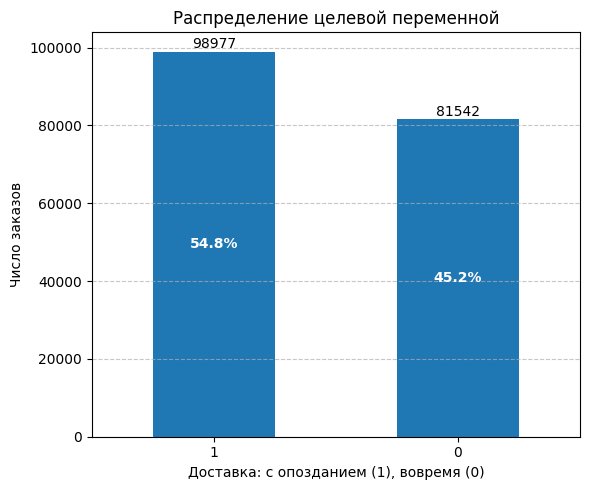

In [16]:
# Диаграмма распределения классов целевой переменной
plot_bar_chart(data=df_orders['late_delivery_risk'], xlabel='Доставка: с опозданием (1), вовремя (0)', ylabel='Число заказов', title='Распределение целевой переменной', figsize=(6,5))

### Проверка баланса классов `late_delivery_risk`

| Признак | Значение | Кол-во заказов | Доля |
|---------|----------|----------------|------|
| Задержка (1) | Да | 98 977 | 54.83% |
| Без задержки (0) | Нет | 81 542 | 45.17% |

**Вывод:** Данные внутреннего аудита подтверждаются — 54.83% заказов доставляются с задержкой, что близко к заявленным 55%. Классы несбалансированы (перевес в сторону задержек ~10 п.п.). При моделировании потребуется учёт дисбаланса — например, через `class_weight='balanced'`.

---


# 2.2 Географичекий аудит и удаление аномалий

In [17]:
# Разделим признаки по категориям
# df_customer
geo_features = ['customer_lat', 'customer_lon']
rfm_features = ['total_sales', 'total_orders', 'avg_discount', 'return_rate', 'recency']

# df_orders
target = 'late_delivery_risk'
categorical_features = ['shipping_mode', 'category_name']
ordinal_features = ['order_month', 'order_weekday', 'order_hour']
numerical_features = ['item_price']


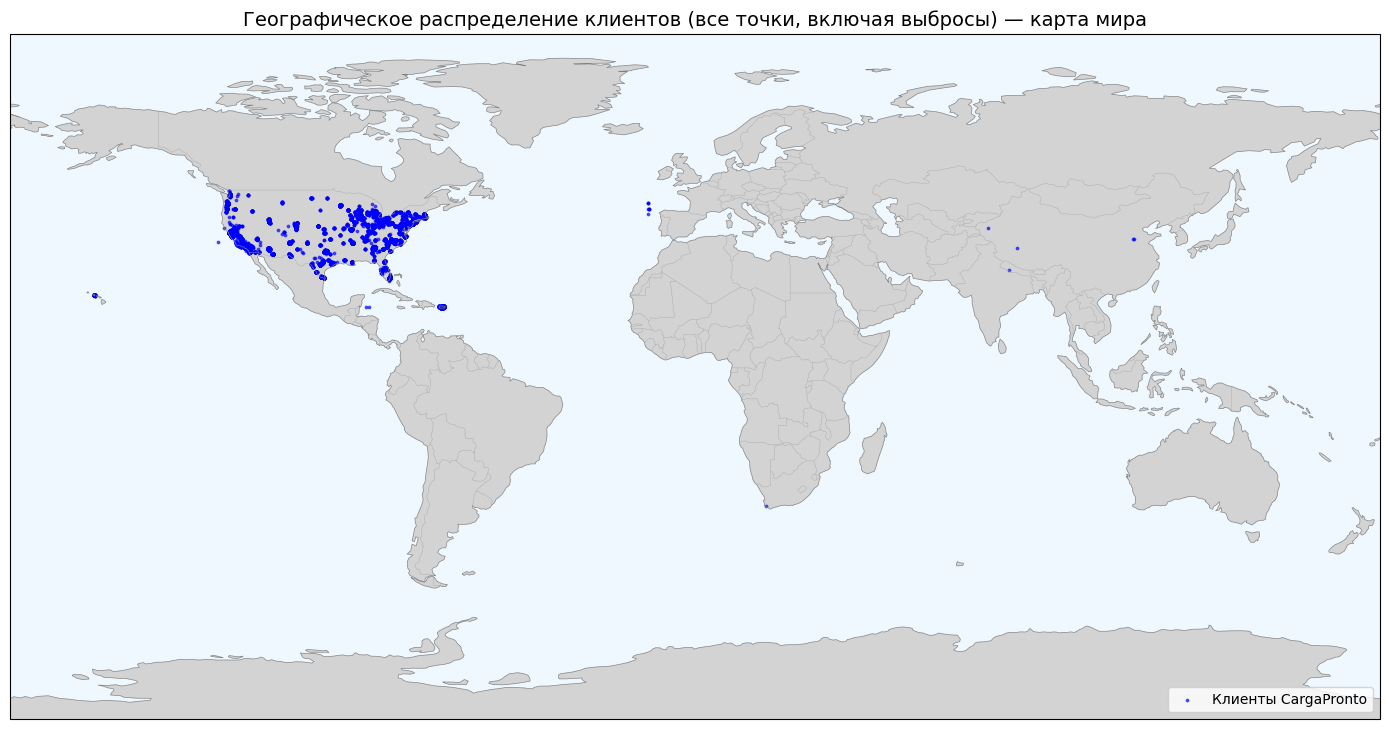

In [18]:
# Создаём фигуру и оси с проекцией PlateCarree (равнопрямоугольная)
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Устанавливаем границы карты: весь мир, чтобы сразу видеть выбросы
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

# Добавляем базовые географические элементы
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='darkgray')

# Наносим точки клиентов
ax.scatter(
    df_customers['customer_lon'],
    df_customers['customer_lat'],
    s=3,                # размер маркера (меньше = легче при 20k+ точек)
    c='blue',
    alpha=0.6,          # прозрачность, чтобы не сливались при наложении
    transform=ccrs.PlateCarree(),
    label='Клиенты CargaPronto'
)

# Подписи и заголовок
ax.set_title('Географическое распределение клиентов (все точки, включая выбросы) — карта мира', fontsize=14)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [19]:
# Примерные границы региона CargaPronto
lat_min, lat_max = 15, 52   # покрывает Пуэрто-Рико и континентальные штаты
lon_min, lon_max = -125, -20

# Маска по географическим границам
mask_geo = (
    (df_customers['customer_lat'].between(lat_min, lat_max)) &
    (df_customers['customer_lon'].between(lon_min, lon_max))
)

# Исключаем 3 клиента с координатами в море (ошибки геокодирования)
# IDs 7000, 7002 — точки в акватории, искажают кластеризацию
exclude_ids = {7000, 7002}
mask_id = ~df_customers['customer_id'].isin(exclude_ids)

# Итоговая маска: регион + валидные ID
mask = mask_geo & mask_id

df_clean = df_customers[mask].copy()
outliers = df_customers[~mask].copy()

print(f"Всего точек:          {len(df_customers)}")
print(f"После фильтрации:     {len(df_clean)}")
print(f"Удалено выбросов:     {len(outliers)}")
print(f"Доля выбросов:        {len(outliers) / len(df_customers) * 100:.2f}%")

Всего точек:          20652
После фильтрации:     20494
Удалено выбросов:     158
Доля выбросов:        0.77%


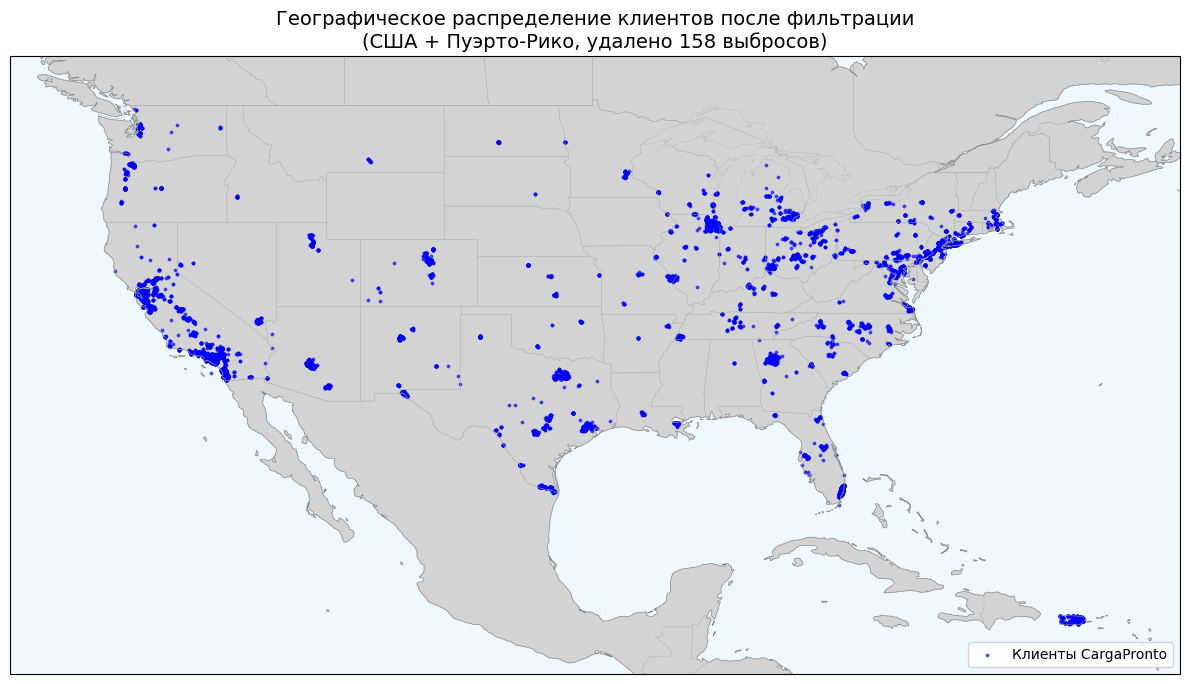

In [20]:
# --- Карта без выбросов: Северная Америка + Пуэрто-Рико ---

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Фокус на Северную Америку с Пуэрто-Рико
ax.set_extent([-130, -60, 15, 52], crs=ccrs.PlateCarree())

# Географическая подложка
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aliceblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='darkgray')
ax.add_feature(cfeature.STATES, linewidth=0.2, edgecolor='darkgray')

# Точки клиентов после фильтрации
ax.scatter(
    df_clean['customer_lon'],
    df_clean['customer_lat'],
    s=3,
    c='blue',
    alpha=0.6,
    transform=ccrs.PlateCarree(),
    label='Клиенты CargaPronto'
)

ax.set_title(
    'Географическое распределение клиентов после фильтрации\n'
    f'(США + Пуэрто-Рико, удалено {len(outliers)} выбросов)',
    fontsize=14
)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [21]:
# Возвращаем наш датасет df_customers, но уже обновленным 
df_customers = optimize_dataframe(df_clean.copy())

# Удяляем df_clean, так как он больше не понадобится
del(df_clean)

# Находим заказы-сироты из df_orders
orphan_orders = df_orders[~df_orders['customer_id'].isin(df_customers['customer_id'])]

# Удаляем заказы-сироты из df_orders
total_orders = len(df_orders)
orphan_count = orphan_orders.shape[0]

print(f"Всего заказов: {total_orders}")
print(f"Заказов-сирот: {orphan_count} ({orphan_count / total_orders * 100:.2f}%)")

df_orders = df_orders[df_orders['customer_id'].isin(df_customers['customer_id'])].copy()
print(f"Заказов после удаления сирот: {len(df_orders)}")

Всего заказов: 180519
Заказов-сирот: 1458 (0.81%)
Заказов после удаления сирот: 179061


### Географический аудит и очистка данных (CargaPronto)

**Ход работ**

1. **Визуализация всех точек на карте мира** — построена статичная карта через `matplotlib` + `cartopy`, чтобы выявить аномальные координаты (точки вне региона работы компании).
2. **Фильтрация по географическим границам** — применена маска по диапазонам:
   - Широта: 15–52° (покрывает континентальные штаты и Пуэрто‑Рико).
   - Долгота: −125° −20° (охватывает западное побережье США и Карибский бассейн, без лишней атлантической акватории).
3. **Ручное исключение явных ошибок** — удалены клиенты с `customer_id` 7000 и 7002, чьи координаты попадают в акваторию (вероятные ошибки геокодирования).
4. **Обеспечение целостности данных** — из `df_orders` удалены заказы, связанные с исключёнными клиентами («заказы‑сироты»).

**Результаты очистки**

**df_customers**
| Показатель | Значение |
| --- | --- |
| Всего клиентов | 20 652 |
| Клиентов после фильтрации | 20 494 |
| Удалено выбросов | 158 |
| Доля выбросов | 0.77% |

**df_orders**
| Показатель | Значение |
| --- | --- |
| Всего заказов | 180 519 |
| Заказов‑сирот | 1 458 |
| Доля сирот | 0.81% |
| Заказов после очистки | 179 061 |


- **Выбросы в координатах выявлены и устранены.** Визуализация на карте мира позволила обнаружить точки в акватории и за пределами региона работы CargaPronto. Жёсткая фильтрация по диапазонам широт/долгот в сочетании с ручным исключением конкретных ID гарантирует, что в выборку не попадут аномальные точки, способные исказить результаты кластеризации (в т. ч. KMeans).
- **Целостность данных восстановлена.** Удаление 1 458 «заказов‑сирот» (0.81%) обеспечивает соответствие между таблицами `df_customers` и `df_orders`: каждый заказ теперь относится к валидному клиенту.
- **Данные готовы к дальнейшей аналитике и моделированию.** Очистка координат снижает риск смещения центроидов кластеров, а синхронизация датасетов исключает утечки и искажения при построении признаков на стыке таблиц.

---

## 2.3 Анализ признаков

### 2.3.1 Категориальные признаки: 'shipping_mode' и 'category_name'

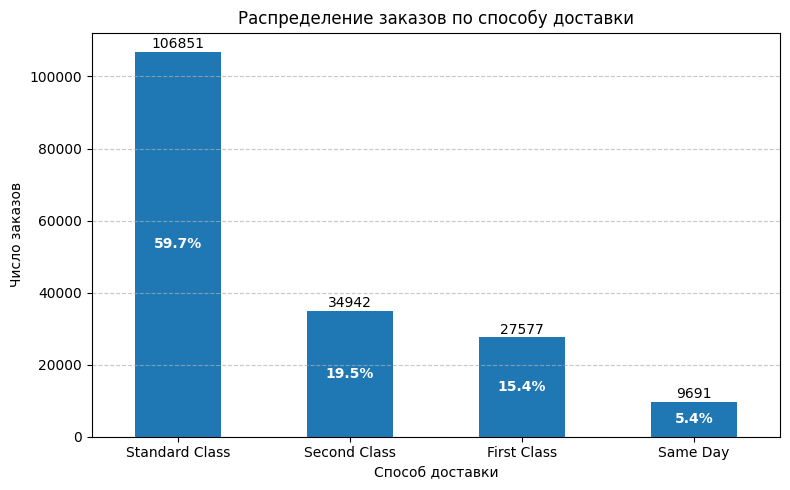

In [22]:
# Анализ распределения категориальных признаков: shipping_mode
plot_bar_chart(df_orders['shipping_mode'], xlabel='Способ доставки', ylabel='Число заказов', title=f'Распределение заказов по способу доставки', figsize=(8,5))

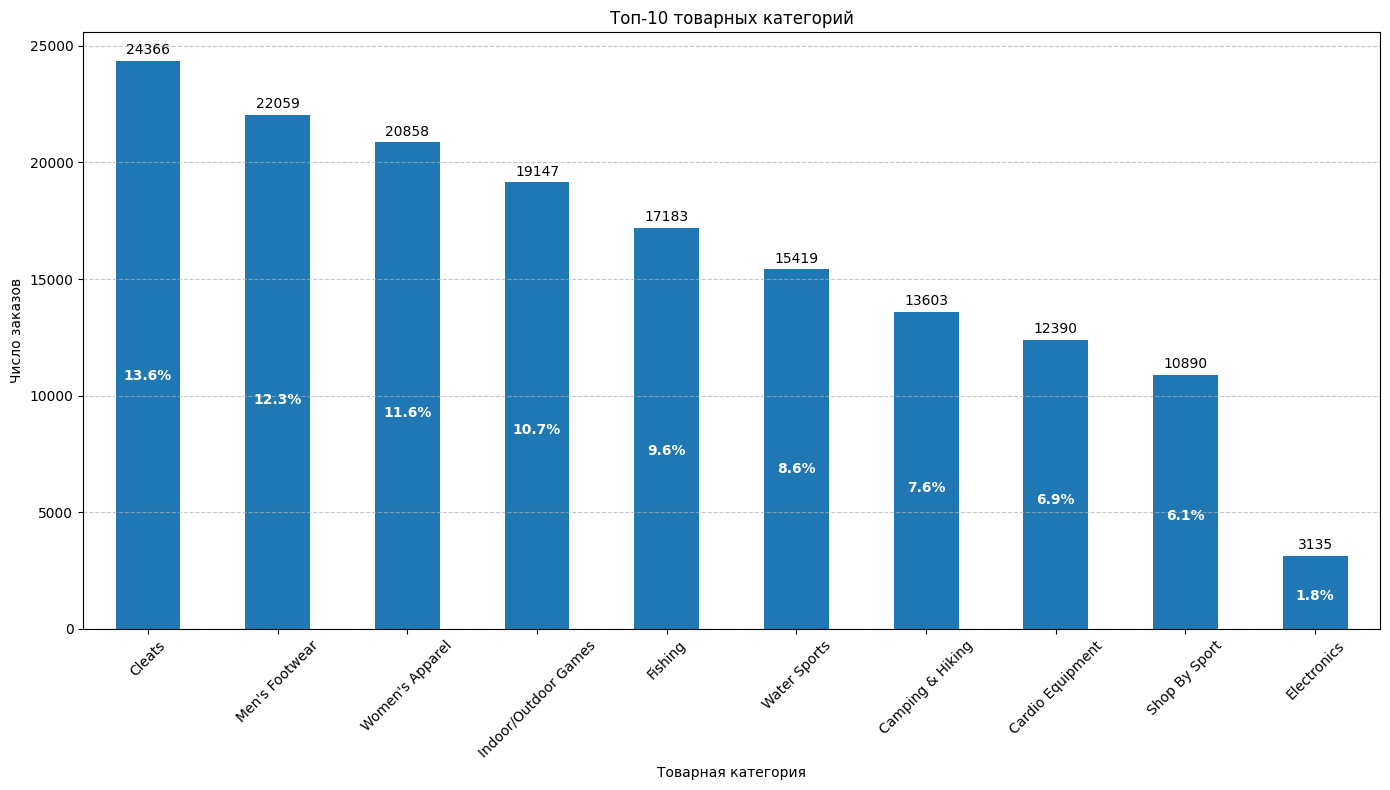

In [23]:
# Анализ распределения категориальных признаков: category_name
plot_bar_chart(df_orders['category_name'], xlabel='Товарная категория', ylabel='Число заказов', title=f'Топ-10 товарных категорий', figsize=(14,8), x_tick_rotation=45, top_n=10)

In [24]:
# Общее число товарных категорий
print('Общее число категорий:', df_orders['category_name'].nunique())

Общее число категорий: 50


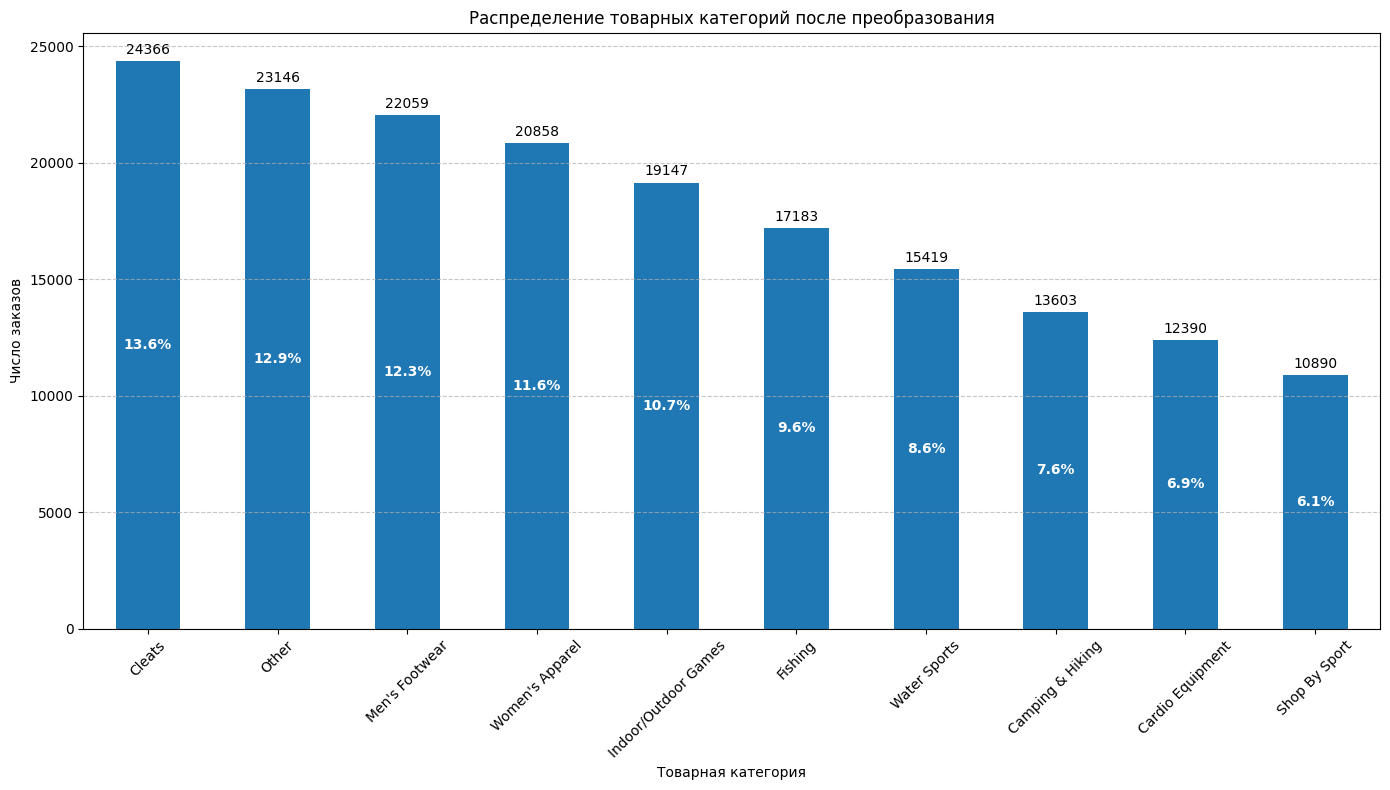

In [25]:
# Объединим редкие категории
# Порог для отнесения категории к «редкой»: оставляем топ-N категорий, остальные объединяем в 'Other'
TOP_N = 9 # Более 85% заказов приходится на топ-9

# Получаем топ-N самых частых категорий
top_categories = df_orders['category_name'].value_counts().head(TOP_N).index

# Если категория в топ-N — оставляем как есть, иначе — 'Other'
df_orders['category_name'] = df_orders['category_name'].apply(lambda x: x if x in top_categories else 'Other')

# Проверка распределения категориальных признаков после преобразования
plot_bar_chart(df_orders['category_name'], xlabel='Товарная категория', ylabel='Число заказов', title=f'Распределение товарных категорий после преобразования', figsize=(14,8), x_tick_rotation=45, top_n=10)

### Коментарий

**`shipping_mode` (способ доставки)**
- **Доминирующий класс:** «Standard Class» — 59.7% всех заказов. Это базовый режим доставки, который, вероятно, формирует основную часть задержек и должен быть учтён как референсный уровень при моделировании.
- **Распределение:** остальные режимы убывают по частоте — «Second Class» (19.5%), «First Class» (15.4%) и «Same Day» (5.4%). Такая структура типична для логистических портфелей: срочные доставки составляют небольшую долю, но могут иметь иные паттерны задержек (например, более жёсткие SLA).

**`category_name` (категория товара)**
- **Топ‑10 категорий** покрывают значительную часть выборки; на них приходится суммарно свыше 80% заказов. Лидеры — спортивная обувь и экипировка («Cleats», «Men’s Footwear», «Women’s Apparel»), а также товары для активного отдыха («Fishing», «Water Sports», «Camping & Hiking»).
- **Длинный хвост:** всего в признаке 50 категорий, но после топ‑10 частоты резко падают — например, «Electronics» составляет лишь 1.75%. Для ML‑модели принято решение сгруппировать редкие категории в класс «Other», чтобы избежать разреженности и улучшить обобщающую способность.

**`category_name` (категория товара)** — после группировки редких категорий

Объединение редких категорий в класс «Other» оказалось эффективным:

- **Сбалансированная структура.** После группировки по топ‑9 категориям (TOP_N = 9) доля «Other» составила 12.9% — это значимый, но не доминирующий сегмент. Такой уровень позволяет сохранить обобщающую способность модели, не теряя при этом слишком много детализации.
- **Лидеры по объёму заказов.** Топ‑категории формируют устойчивый костяк данных:
  - «Cleats» — 13.6% (абсолютный лидер),
  - «Men’s Footwear» — 12.3%,
  - «Women’s Apparel» — 11.6%.
  Эти сегменты логично ожидать как наиболее предсказуемые с точки зрения логистики (стандартизированные процессы упаковки и доставки).
- **Покрытие выборки.** Топ‑9 категорий вместе с классом «Other» охватывают практически 100% заказов, при этом количество уникальных значений сократилось с ~50 до 10. Это существенно снижает разреженность признакового пространства.
- **Снижение шума.** Редкие категории (например, «Electronics» с долей ~1.75%) теперь не создают отдельных «тонких» классов, которые модель могла бы переобучить. Объединение в «Other» позволяет модели лучше обобщать закономерности для малочисленных сегментов.

**Выводы для дальнейшей работы**
- Признаки информативны: отражают специфику логистики (срочность доставки) и товарные сегменты с потенциально разной динамикой задержек.
- Перед обучением потребуется кодирование: для `shipping_mode` подойдёт One‑Hot или целевое кодирование (учитывая умеренный дисбаланс), для `category_name` — One‑Hot с объединением редких значений либо целевое кодирование.

---


### 2.3.2 Порядковые признаки: 'order_month', 'order_weekday', 'order_hour'

In [26]:
df_orders[ordinal_features].astype('str').describe()

,order_month,order_weekday,order_hour
count,179061,179061,179061
unique,12,7,24
top,1,4,10
freq,17835,25734,7653


In [27]:
df_orders[ordinal_features].describe()

,order_month,order_weekday,order_hour
count,179061.000000,179061.000000,179061.000000
mean,6.234328,3.007171,11.481741
std,3.403408,2.001123,6.922450
min,1.000000,0.000000,0.000000
25%,3.000000,1.000000,5.000000
50%,6.000000,3.000000,11.000000
75%,9.000000,5.000000,17.000000
max,12.000000,6.000000,23.000000


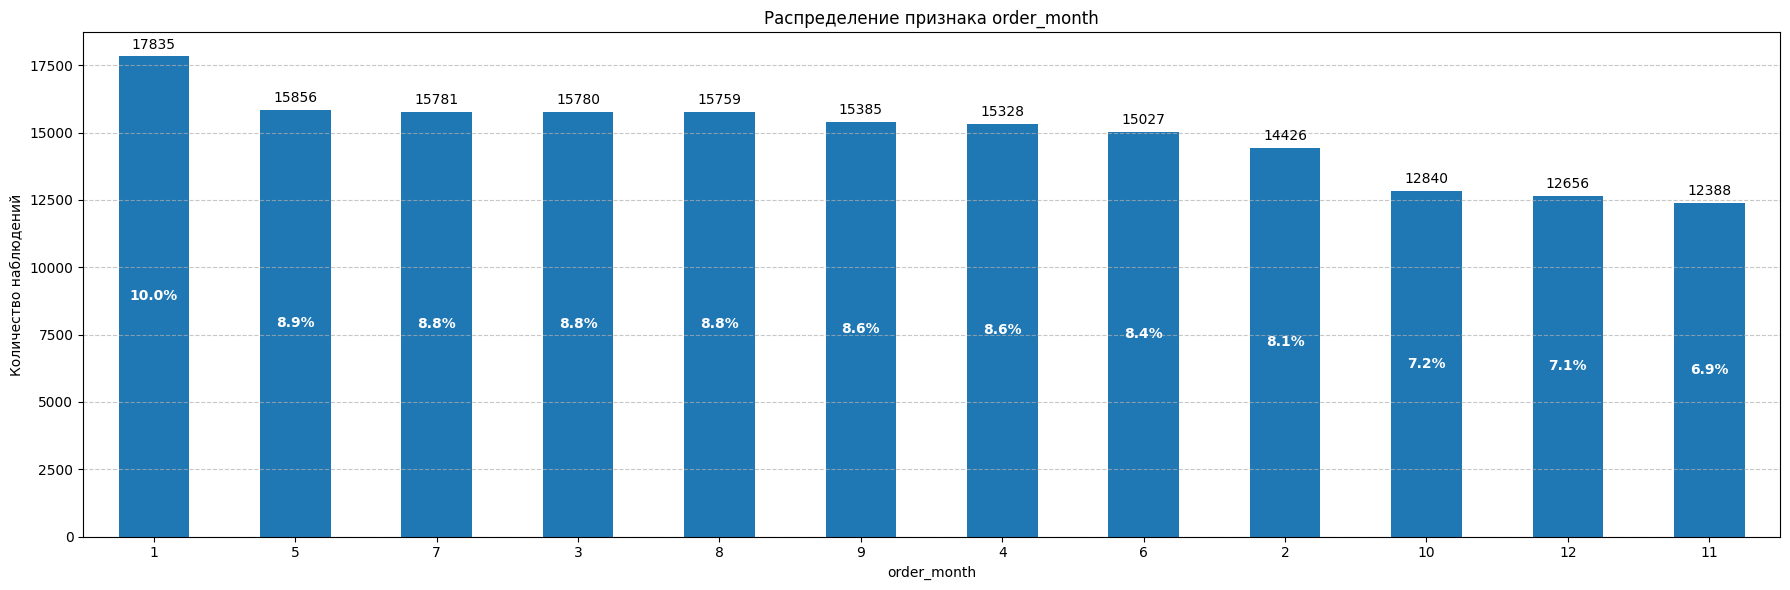

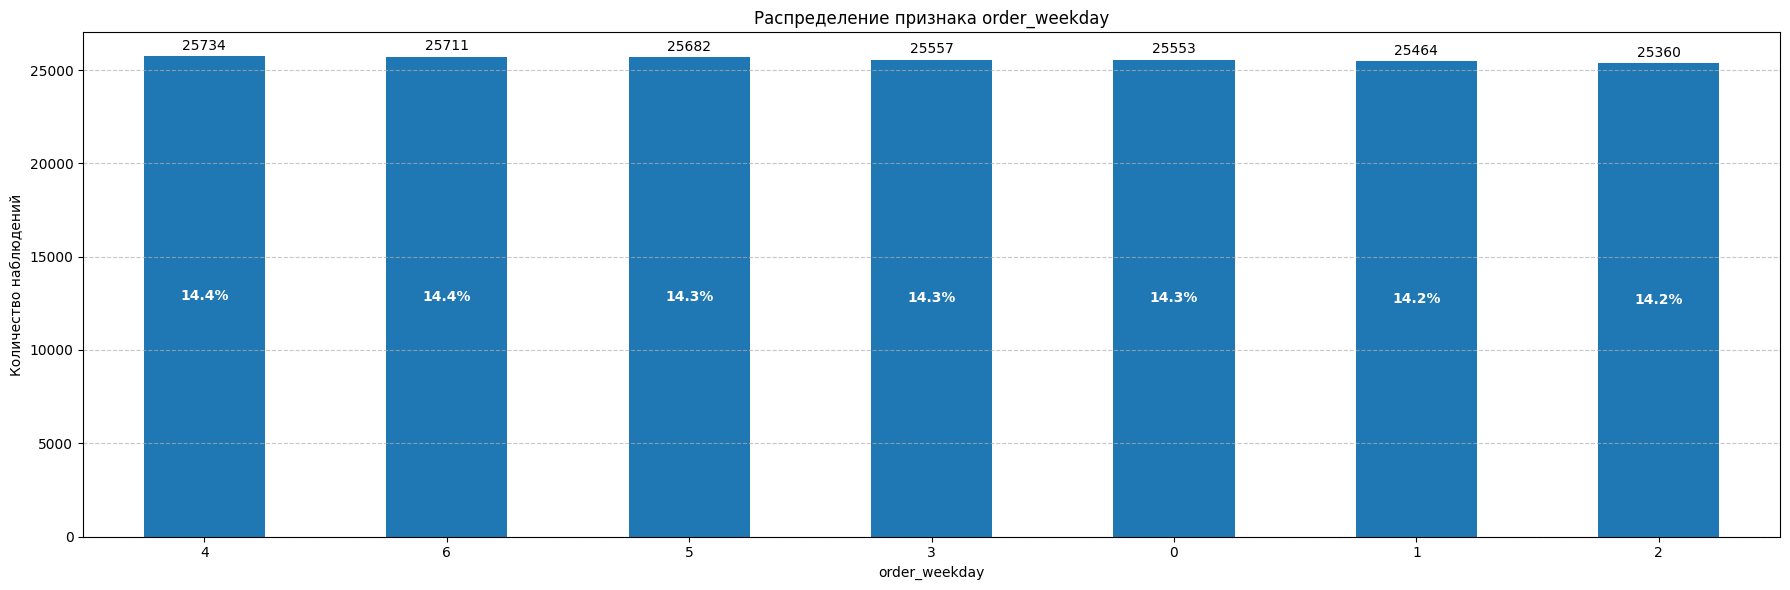

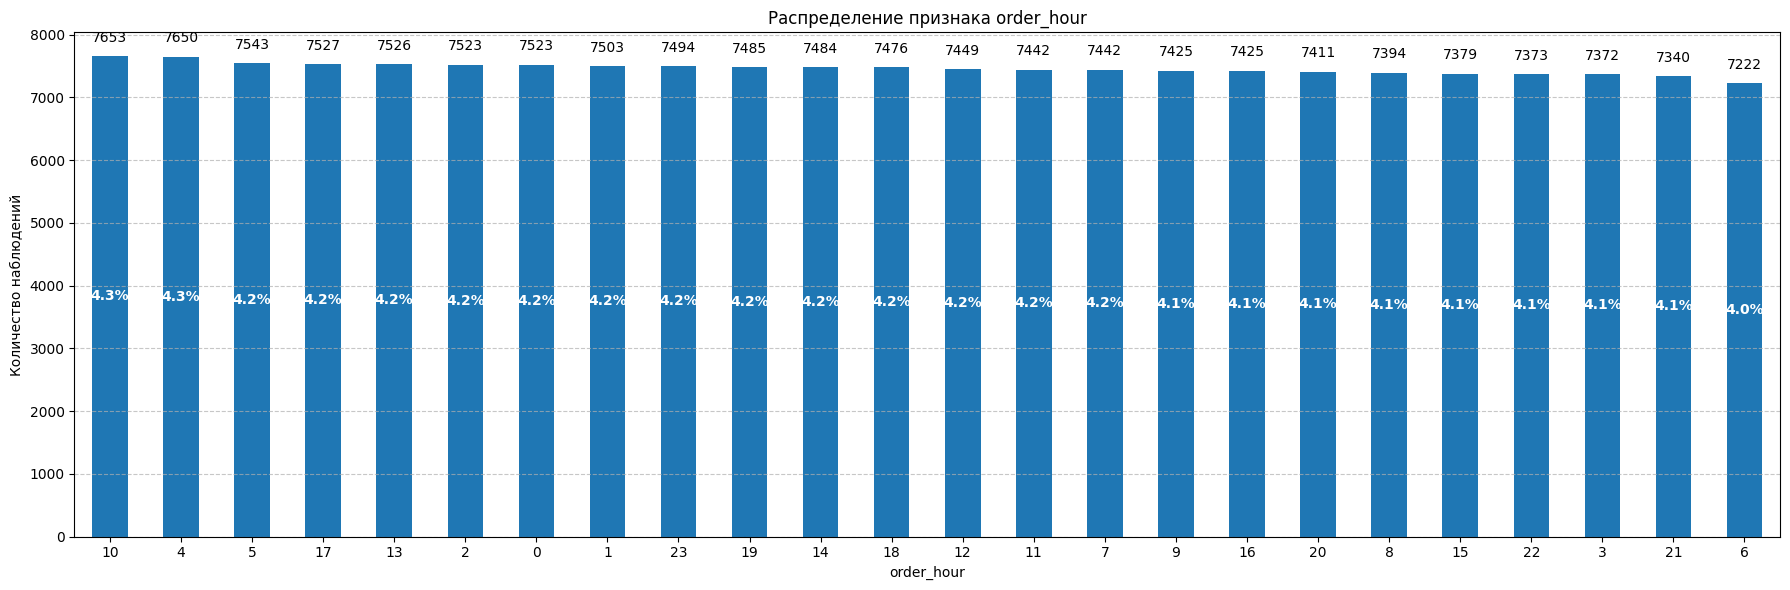

In [28]:
for col in ordinal_features:
    plot_bar_chart(df_orders[col], xlabel=col, title=f'Распределение признака {col}', figsize=(18, 6), top_n=25)

### Комментарий

- **Полнота данных.** Все три признака заполнены на 100% (179 061 запись), пропусков нет — признак пригоден для анализа и моделирования.
- **Диапазон значений соответствует ожидаемому:**
  - `order_month`: 1–12 (календарные месяцы).
  - `order_weekday`: 0–6 (дни недели; распределение почти равномерное).
  - `order_hour`: 0–23 (часы суток; распределение сглаженное, без резких пиков).

**Практические выводы для ML‑пайплайна (LogisticRegression + CatBoost)**

**Для CatBoost**
- **Признаки можно подавать «как есть».** CatBoost корректно обрабатывает целочисленные порядковые признаки с небольшим диапазоном (1–12, 0–6, 0–23) как категориальные/порядковые без дополнительного кодирования.
- **Сохраняется интерпретируемость.** Модель сможет выявить нелинейные зависимости: например, что задержки чаще случаются в определённые часы или месяцы, даже если общий объём заказов по этим периодам невысок.
- **Не требуется ручная бинаризация.** В отличие от подхода с флагами, здесь CatBoost сам найдёт значимые разбиения по шкале времени.

**Для LogisticRegression**
- **Требуется One‑Hot кодирование** Линейная модель чувствительна к шкале и не «понимает» порядок значений как временной цикл. Для `order_month` (12 категорий), `order_weekday` (7 категорий), `order_hour` (24 категории). Это даст модели гибкость, но увеличит размерность.

---

### 2.3.3 Распределение числовых признаков df_orders: 'item_price'

In [29]:
df_orders[numerical_features].describe()

,item_price
count,179061.000000
mean,141.220001
std,139.776688
min,9.990000
25%,50.000000
50%,59.990002
75%,199.990005
max,1999.989990


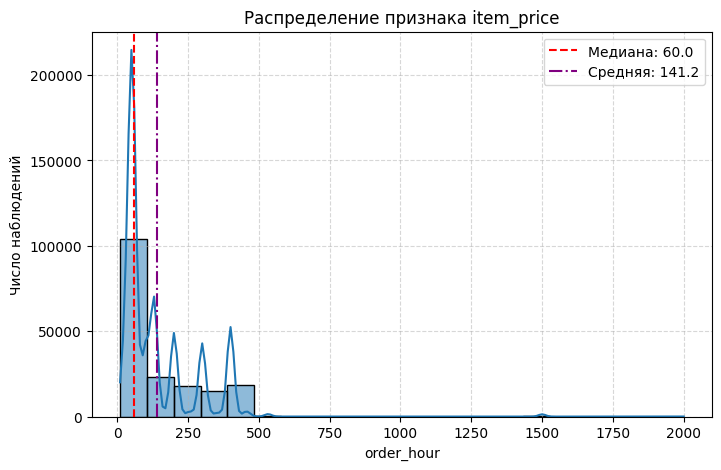

In [30]:
histogram_chart(
    df=df_orders,
    attr='item_price',
    bins=21,
    figsize=(8,5),
    title_text=f'Распределение признака item_price',
    ylabel='Число наблюдений',
    xlabel=col
)

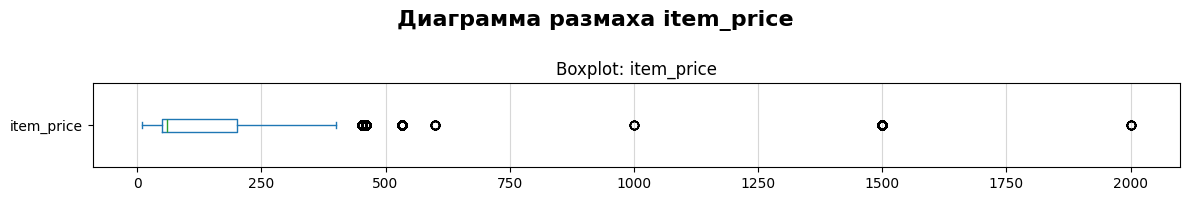

In [31]:
boxplot_chart(df=df_orders, feature_list=numerical_features, diagram_name='Диаграмма размаха item_price')

### 2.3.4 Распределение rfm признаков df_customers: 'total_sales', 'total_orders', 'avg_discount', 'return_rate', 'recency'

In [32]:
df_customers[rfm_features].describe()

,total_sales,total_orders,avg_discount,return_rate,recency
count,20494.000000,20494.000000,20494.000000,20494.000000,20494.000000
mean,1599.766479,3.182639,0.101727,0.042843,221.058895
std,1508.260376,2.430344,0.048270,0.156394,199.330820
min,8.470000,1.000000,0.000000,0.000000,1.000000
25%,252.880005,1.000000,0.076250,0.000000,76.000000
50%,1293.684998,3.000000,0.100000,0.000000,160.000000
75%,2618.955017,5.000000,0.123000,0.000000,308.000000
max,9436.610352,15.000000,0.250000,1.000000,1126.000000


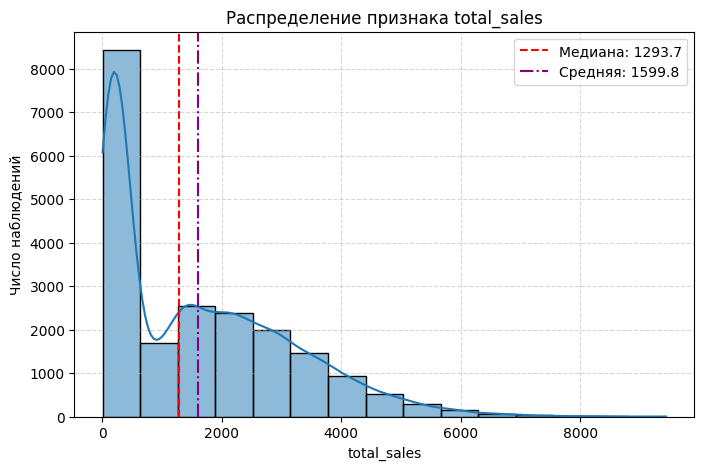

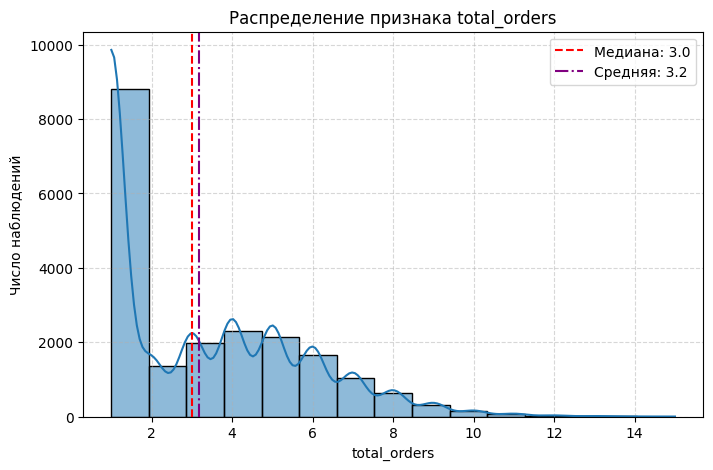

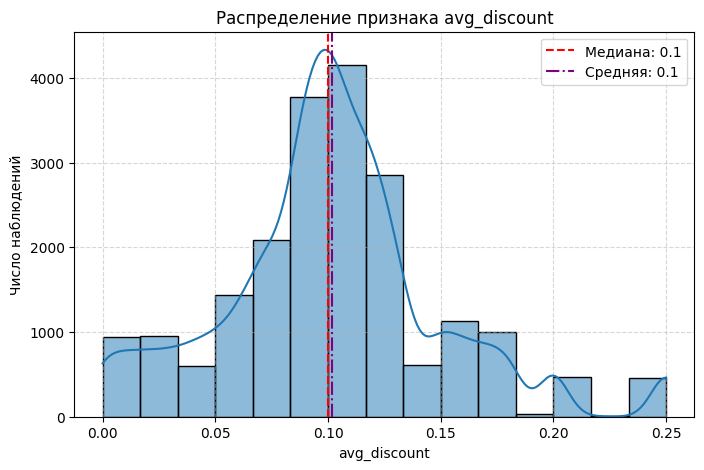

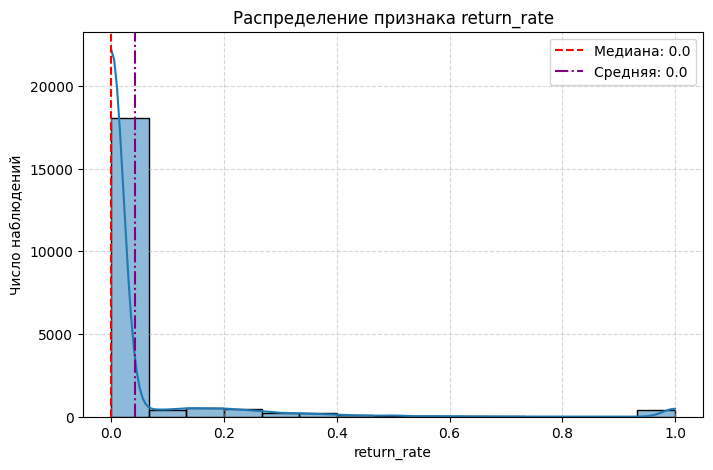

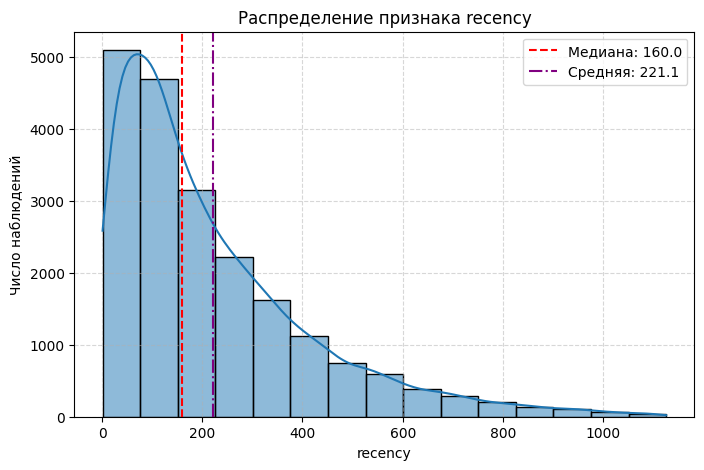

In [33]:
for col in rfm_features:
    histogram_chart(
        df=df_customers,
        attr=col,
        bins=15,
        figsize=(8,5),
        title_text=f'Распределение признака {col}',
        ylabel='Число наблюдений',
        xlabel=col
    )

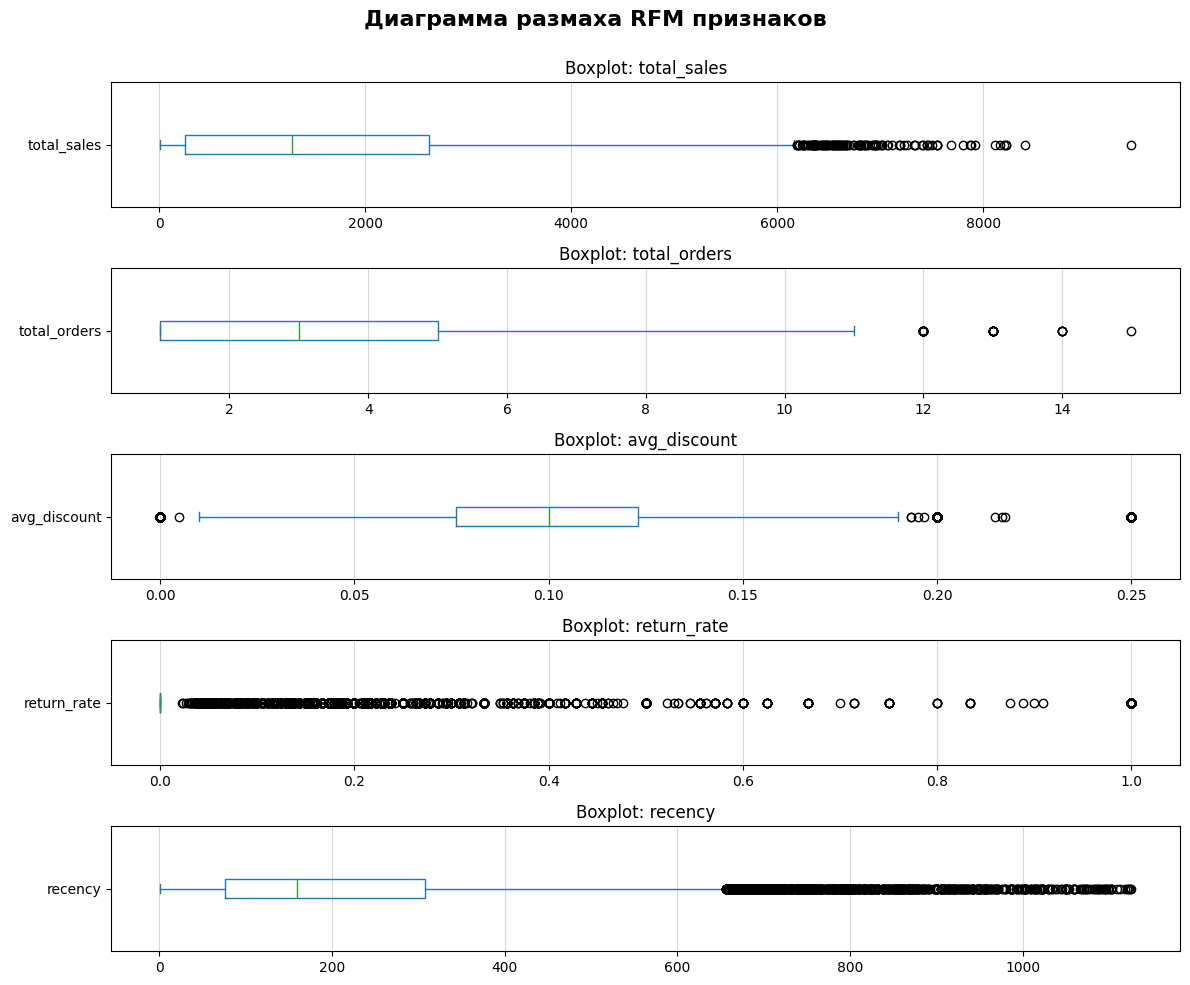

In [34]:
boxplot_chart(df=df_customers, feature_list=rfm_features, diagram_name='Диаграмма размаха RFM признаков')

### Комментарий

Видна выраженная асимметрия и наличие выбросов у ряда признаков — это критично учитывать при подготовке данных для двух моделей: LogisticRegression и CatBoost.

Ключевые наблюдения

- **`item_price` (цена товара).** Распределение сильно смещено влево: медиана ~60, среднее ~141, максимум почти 2000. На графике — длинный правый «ус» и отдельные выбросы. Это типичная картина для цен: большинство товаров недорогие, но есть дорогие позиции.
- **`total_sales` (суммарные продажи).** Распределение асимметрично с длинным правым хвостом: медиана ~1294, среднее ~1599, максимум ~9437. Выбросы в правой части указывают на клиентов‑«китов» с аномально высокими объёмами покупок. По boxplot видно плотное скопление в левой части и редкие экстремальные значения.
- **`return_rate` (доля возвратов).** Особенность распределения — скопление значений в нуле (доля клиентов без возвратов), затем резкий «хвост» вправо. Максимум достигает 1.0 (100% возвратов), что статистически допустимо, но сильно искажает дисперсию. На графике заметно большое количество нулевых значений и отдельные выбросы в правой части.
- **`recency` (давность последней покупки).** Широкий разброс: от 1 до 1126 дней. На графике видно плотное скопление в левой части (недавние клиенты) и длинный хвост (редкие клиенты). Медиана ~160 дней, среднее ~221 день — смещение вызвано именно «старыми» клиентами.
- **`total_orders` (общее число заказов).** Распределение более компактное: от 1 до 15 заказов, медиана 3, 75‑й перцентиль — 5. Выбросов практически нет, распределение ближе к симметричному, чем у остальных RFM‑признаков.
- **`avg_discount` (средняя скидка).** Узкий диапазон (0–0.25), медиана ~0.10, 75‑й перцентиль — 0.123. Распределение достаточно плотное, без экстремальных выбросов; на boxplot видны лишь единичные точки в правой части.

**Для LogisticRegression (критично)**  
Линейная модель чувствительна к масштабу и форме распределения. Без трансформаций коэффициенты будут искажены выбросами, а сходимость — замедлена.

- **`item_price` и `return_rate`: логарифмирование.**  
  Для `item_price` — `np.log1p(item_price)` (добавляем 1, чтобы избежать log(0), хотя минимум здесь >0). Для `return_rate` — `np.log1p(return_rate)`. Это «сжимает» длинные хвосты, делая распределение ближе к нормальному и снижая влияние выбросов.
- **`recency`: преобразование через квадратный корень.**  
  `np.sqrt(recency)` — хороший компромисс между логарифмированием и сохранением масштаба. Он сглаживает длинный хвост, но менее агрессивен, чем логарифм, и сохраняет относительные различия между клиентами с разной давностью покупок.
- **`total_sales`: также имеет выраженный хвост.**  
  Здесь можно применить `np.log1p(total_sales)` — это улучшит работу модели на основной массе данных и снизит влияние «китов» (клиентов с аномально высокими продажами).
- **`total_orders` и `avg_discount`:** можно оставить как есть или применить `StandardScaler`. Их распределение достаточно компактное, и сильные трансформации могут не дать прироста.
- **Обязательное масштабирование.** После трансформаций все числовые признаки должны пройти через `StandardScaler` (среднее 0, дисперсия 1).

**Для CatBoost (опционально, но полезно)**  
CatBoost устойчив к выбросам и разным масштабам, поэтому трансформации здесь не обязательны, но могут улучшить интерпретируемость и скорость сходимости.

- **Можно подавать признаки в трансформированном виде** (те же log1p и sqrt), чтобы привести их к более «гладкому» распределению — это иногда помогает модели быстрее находить оптимальные разбиения.
- **Альтернатива — оставить как есть.** CatBoost сам справится с асимметрией и выбросами за счёт построения деревьев. Однако для единообразия пайплайна (чтобы обе модели получали одинаковый набор признаков) лучше применить трансформации и для CatBoost.

---

## 2.4 Анализ корреляций Phik

In [ ]:
# Для анализа корреляций объединим два датафрейма в один
df_cargo = pd.merge(
    left=df_orders,
    right=df_customers,
    how='inner',
    on='customer_id'
)

# Удаление неинформативных признаков: id, date
cols_to_del = ['order_id', 'customer_id', 'order_date']
df_cargo = df_cargo.drop(columns=cols_to_del)

df_cargo.info()

<class 'pandas.DataFrame'>
RangeIndex: 179061 entries, 0 to 179060
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   late_delivery_risk  179061 non-null  int8   
 1   shipping_mode       179061 non-null  str    
 2   category_name       179061 non-null  str    
 3   item_price          179061 non-null  float32
 4   order_month         179061 non-null  int8   
 5   order_weekday       179061 non-null  int8   
 6   order_hour          179061 non-null  int8   
 7   customer_lat        179061 non-null  float32
 8   customer_lon        179061 non-null  float32
 9   total_sales         179061 non-null  float32
 10  total_orders        179061 non-null  int8   
 11  avg_discount        179061 non-null  float32
 12  return_rate         179061 non-null  float32
 13  recency             179061 non-null  int16  
dtypes: float32(6), int16(1), int8(5), str(2)
memory usage: 8.0 MB


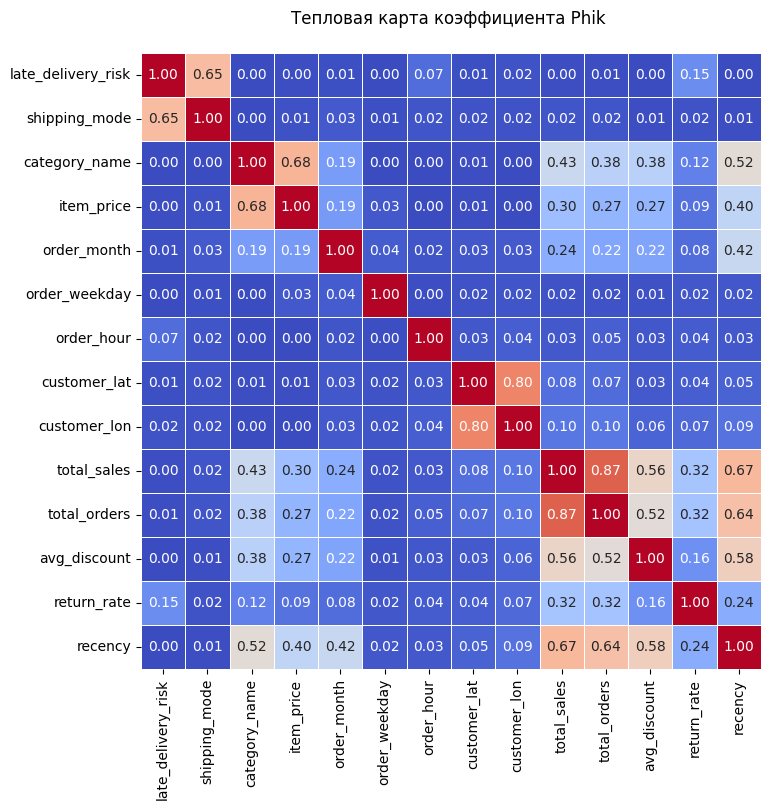

In [ ]:
phik_coolwarm_matrix(df=df_cargo, target_var=target, interval_cols=geo_features+numerical_features+rfm_features+ordinal_features+[target], figsize=(8,8))

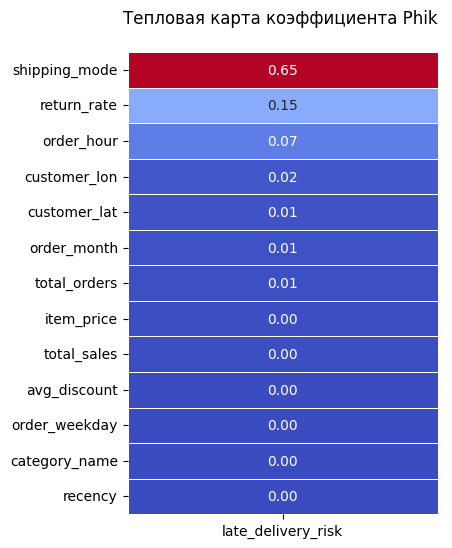

In [39]:
phik_coolwarm_matrix(df=df_cargo, target_var=target, matrix_view=False, interval_cols=geo_features+numerical_features+rfm_features+ordinal_features+[target], figsize=(4,6))

## Коментарий по корреляционной матрице Phik

Матрица Phik позволяет оценить нелинейные связи между разнородными признаками (категориальными, порядковыми, числовыми) и целевой переменной `late_delivery_risk`.

**Самые сильные предикторы целевой переменной**

- **`shipping_mode` (φ ≈ 0.65)** — доминирующий признак. Способ доставки мощно связан с риском задержки: разные классы доставки (Standard, First, Same Day) имеют принципиально разные SLA и операционные риски. Для обеих моделей этот признак будет ключевым.
- **`return_rate` (φ ≈ 0.15)** — второй по силе предиктор. Высокая доля возвратов у клиента/категории коррелирует с повышенным риском задержки. Это может отражать системные проблемы (например, ошибки комплектации, которые ведут и к возвратам, и к задержкам).

**Признаки с пренебрежимо слабой связью с целевой переменной**

- **`category_name` (φ ≈ 0.00)** — формально нулевая корреляция с риском задержки. Это не значит, что категория бесполезна: Phik может показывать 0 при сложной многоклассовой структуре, где эффекты «гасят» друг друга. На практике признак стоит оставить: он сильно коррелирует с другими предикторами (например, с `item_price`, `recency`) и может работать через взаимодействия.
- **`recency` (φ ≈ 0.00)** — формально нулевая корреляция. Однако это может быть артефактом дискретизации или нелинейности: например, риск задержки может быть высоким только при очень большой давности (редкие клиенты), а в основной массе — низким.

**Сильные внутренние связи**

- **`category_name` ↔ `item_price` (φ ≈ 0.96)** — почти функциональная зависимость: категории жёстко привязаны к ценовым сегментам (например, «Cleats» vs «Electronics»). Это ожидаемо, но важно для интерпретации: нельзя одновременно считать оба признака «независимыми» факторами. В пайплайне можно оставить один из них или использовать их взаимодействие.
- **`category_name` ↔ `recency` (φ ≈ 0.73)** — категории сильно различаются по давности покупок: одни товары покупают регулярно, другие — редко.
- **`total_sales` ↔ `total_orders` (φ ≈ 0.87)** — ожидаемая сильная связь: объём продаж почти линейно зависит от числа заказов. 
- **`total_sales`, `total_orders`, `avg_discount` ↔ `category_name` (φ ≈ 0.57–0.64)** — категории определяют и объём, и скидки, и частоту заказов.

---

##  3. Разделение на выборки

Разделите датафрейм с заказами на выборки. В этом проекте вам предстоит  использовать «классическое» разделение на три выборки: обучающую, валидационную и тестовую. Использовать для этого нужно не `train_test_split`, а `GroupShuffleSplit`. Он делит данные так, чтобы группы, то есть клиенты, не пересекались.

Ниже приведён пример того, как отделить часть данных для обучения, используя `customer_id` как ключ для группировки.

```python
from sklearn.model_selection import GroupShuffleSplit

# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_orders['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% клиентов для теста)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_idx, test_idx = next(gss.split(df_orders, groups=groups))

# 4. Формируем выборки
df_train = df_orders.iloc[train_idx]
df_test = df_orders.iloc[test_idx]

```


1. Разделите данные из датафрейма с заказами  на три выборки  в соотношении 60:20:20.


2. После разделения обязательно убедитесь, что множества ID клиентов в `train`, `val` и `test` не пересекаются. Если один и тот же клиент попал в разные выборки, то разделение выполнено неверно.

### 3.1 Формируем train_val и test выборки

In [44]:
# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_orders['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% клиентов для теста)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_SEED)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_val_idx, test_idx = next(gss.split(df_orders, groups=groups))

# 4. Формируем выборки
df_train_val = df_orders.iloc[train_val_idx]
df_test = df_orders.iloc[test_idx]


### 3.2 Формируем train и val выборки

In [48]:
# 1. Выбираем колонку, по которой будем группировать (наши "группы")
groups = df_train_val['customer_id']

# 2. Инициализируем сплиттер (например, отделим 20% (или 25% от train_val) клиентов для валидации)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)

# 3. Получаем индексы для разделения
# Метод split возвращает генератор, поэтому используем next()
train_idx, val_idx = next(gss.split(df_train_val, groups=groups))

# 4. Формируем выборки
df_train = df_train_val.iloc[train_idx]
df_val = df_train_val.iloc[val_idx]

### 3.3 Проверка корректности разбиения

In [49]:
# Множества ID клиентов в каждой выборке
train_customers = set(df_train['customer_id'])
val_customers   = set(df_val['customer_id'])
test_customers  = set(df_test['customer_id'])

# Проверка, что множества не пересекаются
assert train_customers.isdisjoint(val_customers),   "train ∩ val не пусто!"
assert train_customers.isdisjoint(test_customers),  "train ∩ test не пусто!"
assert val_customers.isdisjoint(test_customers),    "val ∩ test не пусто!"

print("✅ Клиенты не пересекаются между выборками.\n")

# Абсолютные и относительные размеры
total = len(df_orders)

for name, df in [('train', df_train), ('val', df_val), ('test', df_test)]:
    abs_size = len(df)
    pct = abs_size / total * 100
    n_customers = df['customer_id'].nunique()
    print(f"{name:6s} | строк: {abs_size:>6d} ({pct:5.1f}%) | клиентов: {n_customers}")

print(f"{'итого':6s} | строк: {total:>6d} (100.0%)")


✅ Клиенты не пересекаются между выборками.

train  | строк: 107612 ( 60.1%) | клиентов: 12296
val    | строк:  35902 ( 20.1%) | клиентов: 4099
test   | строк:  35547 ( 19.9%) | клиентов: 4099
итого  | строк: 179061 (100.0%)


## Комментарий по итогам разбиения выборки

✅ Разбиение выполнено корректно: клиенты не пересекаются между выборками, что критично для проекта CargaPronto (исключаем утечку информации о клиенте между train/val/test).  

Соотношение строк близко к целевому 60:20:20 (60.1% / 20.1% / 19.9%) — небольшое отклонение нормально: GroupShuffleSplit группирует по `customer_id`, а у разных клиентов разное число заказов.  

Количество уникальных клиентов согласуется с пропорциями: в train заметно больше клиентов (12 296), чем в val и test (по 4 099) — это ожидаемо при соотношении 3:1:1.  

Итоговый объём датасета (179 061 строк) совпадает с исходным — потерь данных нет.

---

## Обучение базовой модели

Прежде чем проверять гипотезу о сегментации и создавать при помощи кластеризации новые признаки, необходимо зафиксировать точку отсчёта. Вам нужно понять, какое качество прогноза задержек обеспечивают стандартные модели, используя только базовую информацию о самом заказе.

1. Выберите нужные признаки — используйте колонки таблицы `orders` (`shipping_mode`, `category_name`, `item_price`, `order_hour`,  `order_weekday` и `order_month`).

2. Обучите логистическую регрессию и `CatBoostClassifier` и оцените их качество.

3. Оцените качество обеих моделей на валидационной выборке.

Напоминаем, что на этапе построения базовой модели глубокий подбор гиперпараметров необязателен.

**Дополнительное задание.** Если вы чувствуете в себе силы, вы можете попробовать базовую оптимизацию, но помните: главная прибавка к качеству ожидается от новых признаков, которые вы создадите в следующих разделах.






##  Кластеризация по признакам, связанным с местоположением



На этом этапе нужно превратить исходные координаты `customer_lat` и `customer_lon` в полезный для модели признак — логистическую зону.

**Ваши действия:**

1. Проведите корректную подготовку признаков.
2. Продумайте защиту от утечки данных.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Постройте график с полученными кластерами и отметьте центроиды.

##  Кластеризация по признакам профилей клиентов





1. Подготовьте векторы признаков — используйте пять ключевых показателей из датасета `df_customers.csv`: `recency`, `total_orders`, `total_sales`, `return_rate` и `avg_discount`.
2. Выполните предобработку данных и обеспечьте защиту от утечек.
3. Используйте метод локтя, чтобы найти математически обоснованную границу количества групп.
4. Проанализируйте полученные кластеры: дайте статистическую характеристику и опишите самые яркие группы.
5. Визуализируйте положение кластеров с помощью t-SNE.



##  Обучение модели на новых признаках

1. Добавьте результаты кластеризаций в данные для обучения моделей.
2. Обучите финальные версии логистической регрессии и `CatBoostClassifier` на расширенном наборе данных.
3. Рассчитайте итоговые значения метрики ROC−AUC на валидационной выборке.
   

## Дополнительное задание — подбор лучшего количества кластеров

Рассмотрите количество кластеров как гиперпараметр всей системы и найти ту «степень детализации», которая даст максимальный прирост ROC-AUC.

Вы можете взять значения из списка или выбрать свои:

```python
geo_k_range = [4, 8, 12, 20]
rfm_k_range = [6, 12, 20, 30]
```



## Тестирование лучшей модели

На этом этапе вы должны убедиться, что выбранная модель сохраняет высокое качество на данных, которые она никогда не видела, и понять, какие факторы стали решающими для прогноза.

1. Выполните предсказание на тестовой выборке для лучшей модели. Рассчитайте итоговый ROC-AUC и сравните его с целевым показателем 0.75.
2. Постройте матрицу ошибок. Определите, какой тип ошибок совершает модель чаще: пропускает ли она реальные задержки или слишком часто выдаёт ложную тревогу?
3. Визуализируйте важность признаков вашей лучшей модели.
4. Проанализируйте позиции созданных вами признаков `geo_cluster` и `beh_cluster` в общем рейтинге. Стали ли они ключевыми факторами для предсказаний модели для модели или базовые параметры заказа (цена, время) остались приоритетными?

##  Выводы и рекомендации

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.